# Data Manipulation with Pandas & Visualization with Matplotlib & Seaborn

**Date:** 05/11/2025

In [2]:
#pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Datos de Melbourne Housing Market

* Suburb: Suburb
* Address: Address
* Rooms: Number of rooms
* Price: Price in Australian dollars
* Method:
  * S - property sold;
  * SP - property sold prior;
  * PI - property passed in;
  * PN - sold prior not disclosed;
  * SN - sold not disclosed;
  * NB - no bid;
  * VB - vendor bid;
  * W - withdrawn prior to auction;
  * SA - sold after auction;
  * SS - sold after auction price not disclosed.
  * N/A - price or highest bid not available.

* Type:
  * br - bedroom(s);
  * h - house,cottage,villa, semi,terrace;
  * u - unit, duplex;
  * t - townhouse;
  * dev site - development site;
  * res - other residential.

* SellerG: Real Estate Agent

* Date: Date sold

* Distance: Distance from CBD in Kilometres
* Regionname: General Region (West, North West, North, North east …etc)
* Propertycount: Number of properties that exist in the suburb.
* Bedroom2 : Scraped # of Bedrooms (from different source)
* Bathroom: Number of Bathrooms
* Car: Number of carspots
* Landsize: Land Size in Metres
* BuildingArea: Building Size in Metres
* YearBuilt: Year the house was built
* CouncilArea: Governing council for the area
* Lattitude: Self explanitory
* Longtitude: Self explanitory

* Melb Data: https://www.kaggle.com/code/dansbecker/handling-missing-values/data?select=melb_data.csv
* Sklearn Cheat Sheet from Datacamp: https://media.datacamp.com/legacy/image/upload/v1676302389/Marketing/Blog/Scikit-Learn_Cheat_Sheet.pdf

# 1 Un modelo básico de aprendizaje de máquina para regresión

Ahora vamos a implementar un primer modelo de aprendizaje de máquina para predecir los valores del precio de las viviendas de Melb

## 1.1 Modelo de K-vecinos más cercanos

El modelo de K-vecinos más cercanos (KNN) para regresión se basa en encontrar los "K" puntos de datos más cercanos al punto de entrada y predecir el valor de la variable objetivo basándose en el promedio de los valores de la etiqueta esas "K" observaciones.

Por ejemplo, si se desea predecir el precio de una casa en función de su tamaño y el número de habitaciones, el modelo KNN buscará las "K" casas más cercanas en tamaño y número de habitaciones, y promediará sus precios para predecir el precio de la casa de entrada.

El modelo KNN utiliza una función de distancia para medir la cercanía entre los puntos de datos. Por lo general, se utiliza la distancia euclidiana, que es la distancia recta entre dos puntos en un espacio de coordenadas.

## 1.2 Procedimiento para entrenar el modelo

En este caso, vamos a experimentar tomando únicamente las variables del clima (`Rooms`, `BuildingArea`, `Landsize`, `Distance`, `Bathroom`) y predeciremos la variable `Price`.

El procedimiento será descrito a continuación:

    * Obtener los datos en forma tabular para las características y etiquetdas deseadas,
    * Dividir el conjunto en entrenamiento y prueba,
    * Ajustar el modelo KNN sobre el conjunto de entrenamiento, midiendo el error.
    * Predecir sobre el conjunto de prueba y medir el error.


In [4]:
DATA_PATH = os.path.join(
    "/Users/cesar/sandbox/ai_programming_foundations/data",
    "melb_data.csv"
)

In [5]:
df = pd.read_csv(DATA_PATH)

Nota: Los objetos de Pandas se llaman **DataFrames**

In [6]:
df #.tail(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,03/12/16,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,04/02/16,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,04/03/17,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,04/03/17,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,04/06/16,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000,S,Barry,26/08/17,16.7,3150,...,2,2.0,652,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392
13576,Williamstown,77 Merrett Dr,3,h,1031000,SP,Williams,26/08/17,6.8,3016,...,2,2.0,333,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380
13577,Williamstown,83 Power St,3,h,1170000,S,Raine,26/08/17,6.8,3016,...,2,4.0,436,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380
13578,Williamstown,96 Verdon St,4,h,2500000,PI,Sweeney,26/08/17,6.8,3016,...,1,5.0,866,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380


In [7]:
df.Regionname.unique()

array(['Northern Metropolitan', 'Western Metropolitan',
       'Southern Metropolitan', 'Eastern Metropolitan',
       'South-Eastern Metropolitan', 'Eastern Victoria',
       'Northern Victoria', 'Western Victoria'], dtype=object)

In [8]:
df.Distance.describe()

count    13580.000000
mean        10.137776
std          5.868725
min          0.000000
25%          6.100000
50%          9.200000
75%         13.000000
max         48.100000
Name: Distance, dtype: float64

In [9]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [10]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

In [11]:
# Columnas para predecir
features = [
    'Rooms', 
    'BuildingArea',
    'Landsize',
    'Distance',
    'Bathroom',
    ]

# columna objectivo a predecir
target = ['Price']

In [12]:
df.filter(features+target).info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rooms         13580 non-null  int64  
 1   BuildingArea  7130 non-null   float64
 2   Landsize      13580 non-null  int64  
 3   Distance      13580 non-null  float64
 4   Bathroom      13580 non-null  int64  
 5   Price         13580 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 636.7 KB


In [13]:
df.filter(features+target).describe()

,Rooms,BuildingArea,Landsize,Distance,Bathroom,Price
count,13580.000000,7130.000000,13580.000000,13580.000000,13580.000000,1.358000e+04
mean,2.937997,151.967650,558.416127,10.137776,1.534242,1.075684e+06
std,0.955748,541.014538,3990.669241,5.868725,0.691712,6.393107e+05
min,1.000000,0.000000,0.000000,0.000000,0.000000,8.500000e+04
25%,2.000000,93.000000,177.000000,6.100000,1.000000,6.500000e+05
50%,3.000000,126.000000,440.000000,9.200000,1.000000,9.030000e+05
75%,3.000000,174.000000,651.000000,13.000000,2.000000,1.330000e+06
max,10.000000,44515.000000,433014.000000,48.100000,8.000000,9.000000e+06


In [14]:
#len(df_plots.columns)

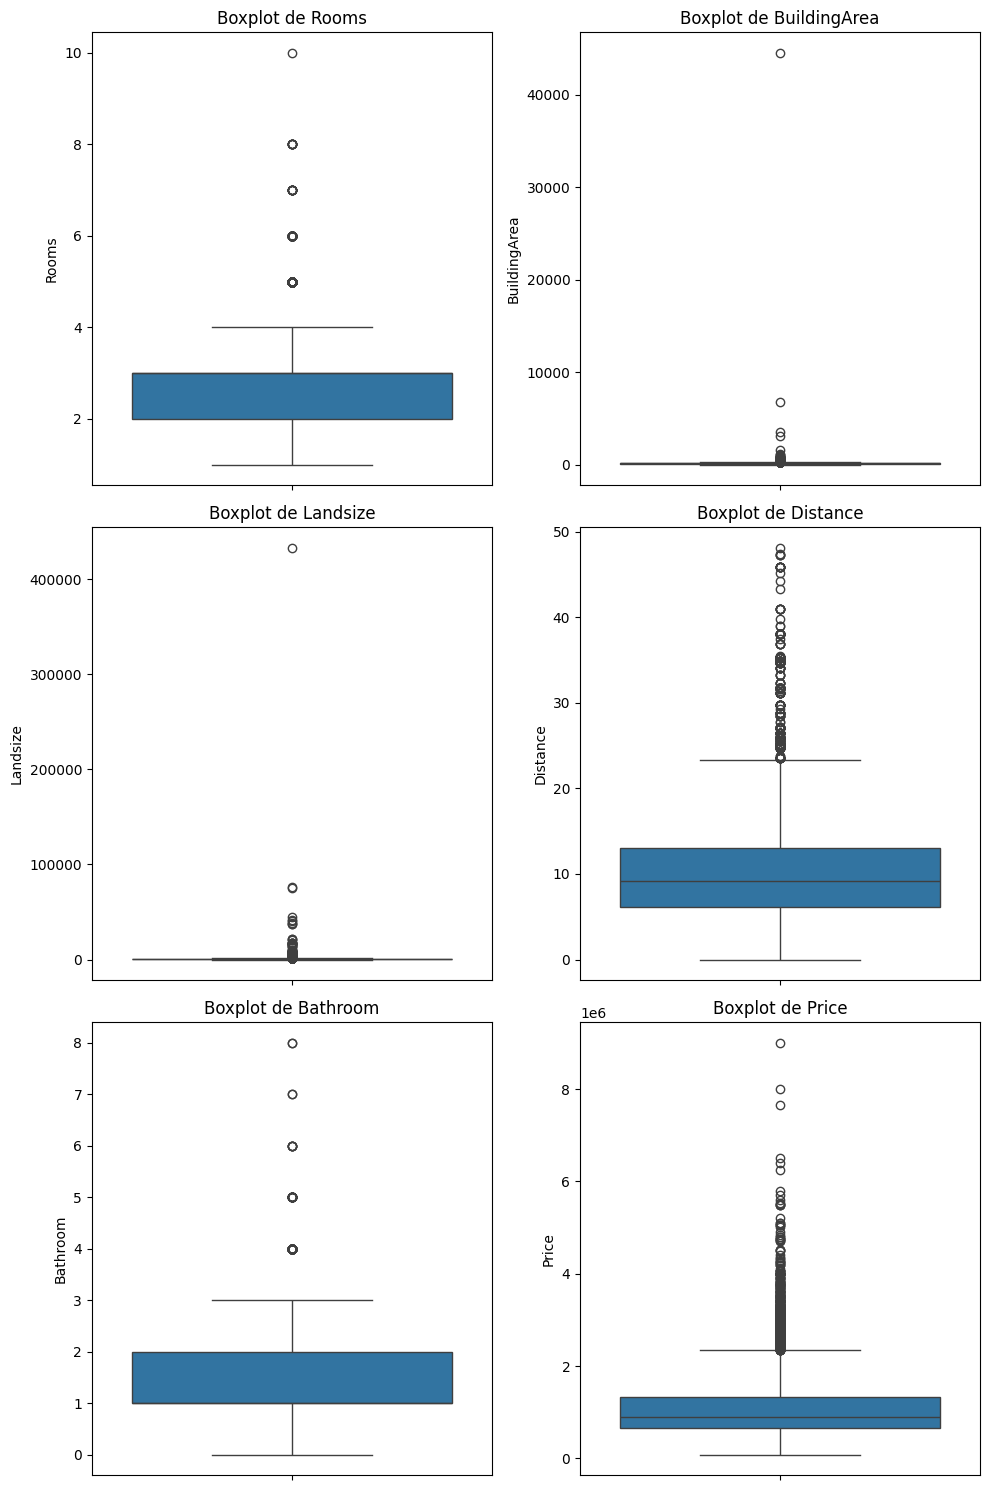

In [15]:
df_plots = df.filter(features+target)

# Determine the number of columns to plot
num_columns = len(df_plots.columns)
# Define the number of columns and calculate the number of rows needed
n_cols = 2 
n_rows = (num_columns + n_cols - 1) // n_cols

# Create a figure and a set of subplots
# Cambiamos la configuración de los subplots a (n_rows, n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5), sharey=False)
axes = axes.flatten()

# Iterate through columns and plot each on its own subplot
for i, col in enumerate(df_plots.columns):
    sns.boxplot(y=df_plots[col], ax=axes[i], orient='v')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col) # Set individual y-axis label

# Ocultar los subplots sobrantes si 'num_columns' no es múltiplo de 'n_cols'
for j in range(num_columns, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

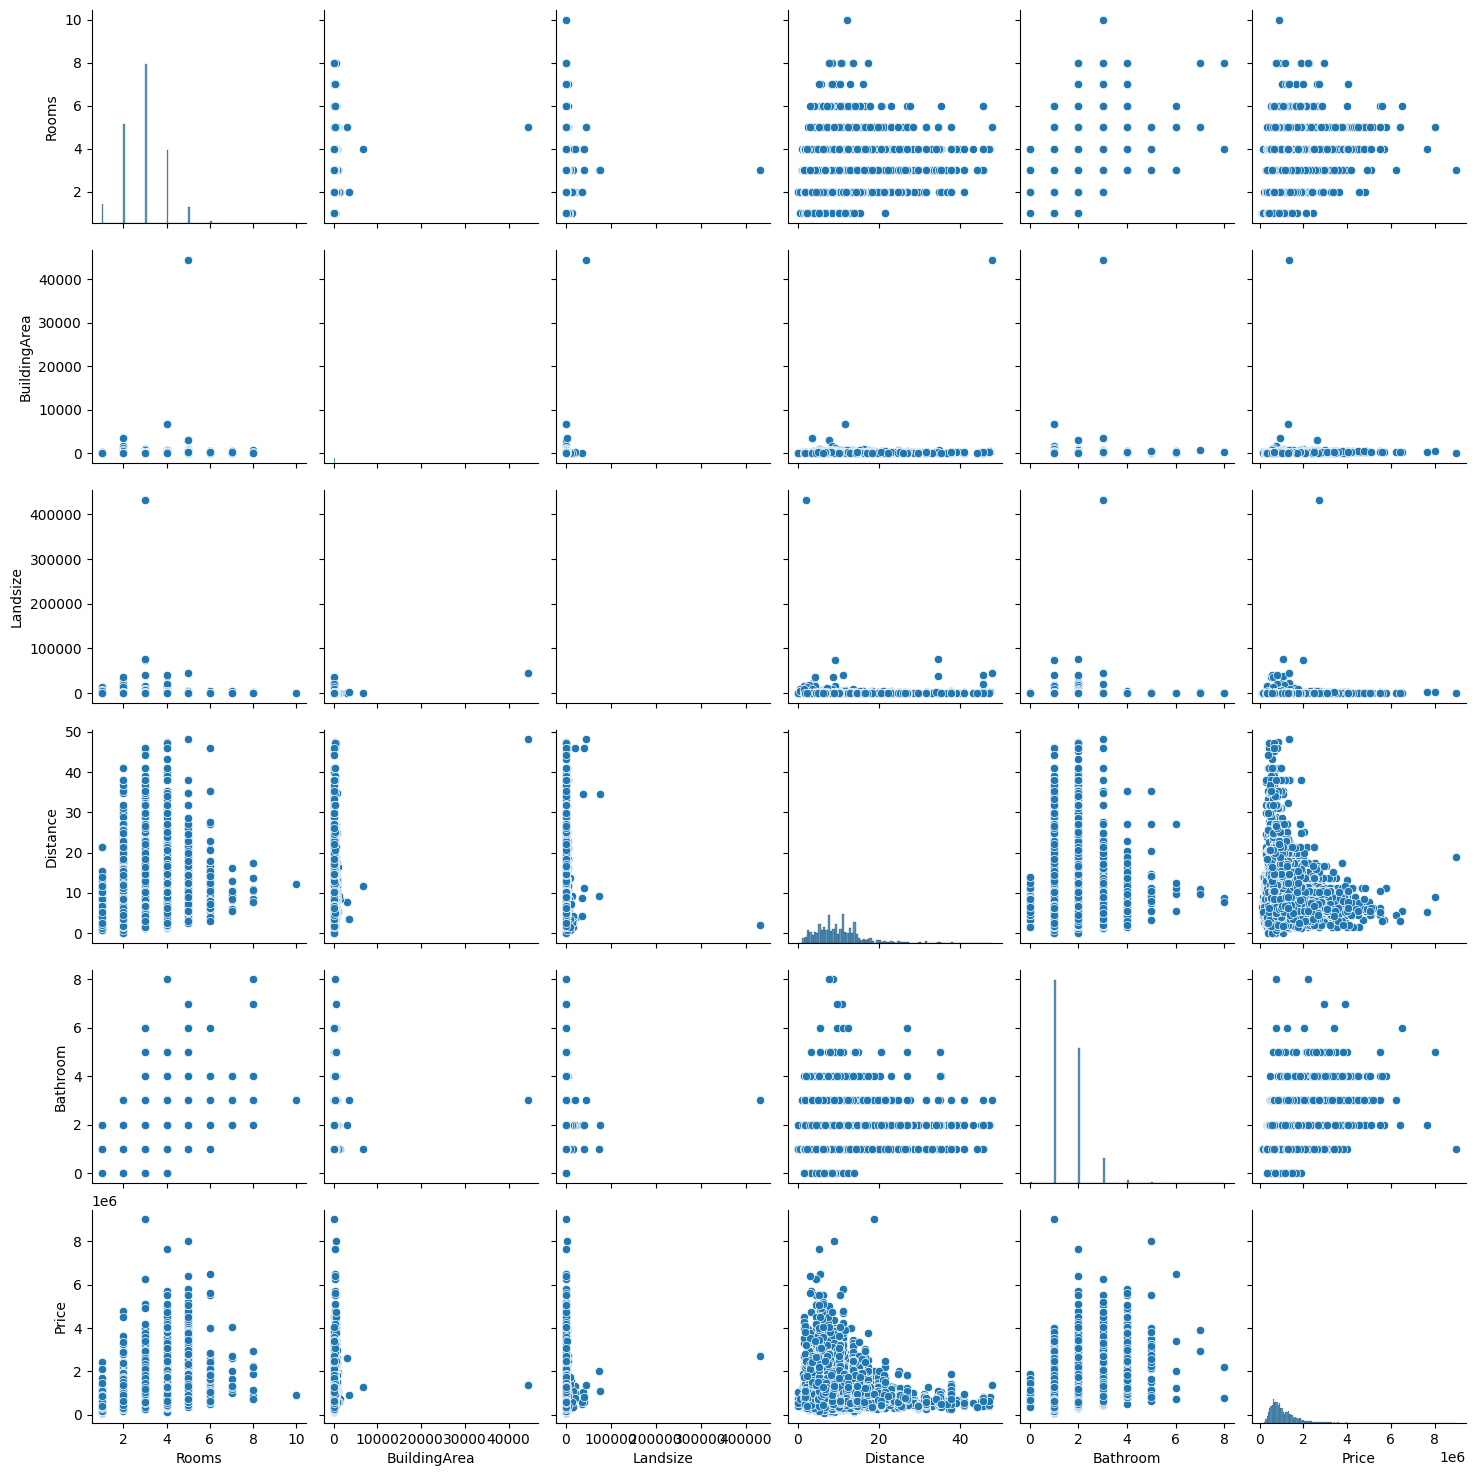

In [16]:
sns.pairplot(
    df.filter(features+target)
)

In [17]:
df[features+target].isna().sum()

Rooms              0
BuildingArea    6450
Landsize           0
Distance           0
Bathroom           0
Price              0
dtype: int64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features].fillna(0),
    df[target],
    test_size=0.2,
    random_state=210
)

## 1.3 Ajustar el modelo KNN sobre el conjunto de entrenamiento, midiendo el error.

En este caso ajustaremos el modelo KNN para regresión de SKlearn, que corresponde a la clase `KNeighborsRegressor` de SKlearn
mediendo el error con `MSE` que corresponde a la función `mean_squared_error` de ésta misma librería.

El flujo a seguir es el siguiente:

* Instanciar la clase del modelo de aprendizaje con los parámetros iniciales
* Ajustar el modelo sobre los datos con el método `.fit(data)`
* Predecir con el modelo entrenado en los datos de entrenamiento y prueba con `.predict(data)`
* Medir el error de ambas predicciones y evaluar.

**Instanciamos el modelo KNN**

In [45]:
# Modelo para 5 vecinos mas cercanos
model = KNeighborsRegressor(n_neighbors=5)

In [46]:
model.__dict__

{'n_neighbors': 5,
 'radius': None,
 'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'p': 2,
 'n_jobs': None,
 'weights': 'uniform'}

**Ajustamos el modelo sobre los datos de entrenamiento**

In [47]:
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


**Predecimos para los datos de entrenamiento y prueba**

In [48]:
# Veamos que podemo predecir con un solo valor ..
X_test.iloc[10] # tomamos un valor

Rooms             5.00
BuildingArea    182.85
Landsize        701.00
Distance         16.70
Bathroom          2.00
Name: 11375, dtype: float64

In [49]:
X_test.iloc[0].values.reshape(1, -1)

array([[ 2. , 62. ,  0. ,  4.6,  1. ]])

In [50]:
model.predict(X_test.iloc[0].values.reshape(1, -1)) # se lo damos al modelo para predecir

/Users/cesar/sandbox/ai_programming_foundations/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


array([[468000.]])

Ahora, predecimos para todos los datos del conjunto de entrenamiento y prueba

In [51]:
# Predecimos para todos los datos del conjunto de entrenamiento y prueba
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

**Medimos el error**

In [52]:
# error en conjunto de entrenamiento
error_train = root_mean_squared_error(y_train, y_train_pred)

# error en conjunto de prueba
error_test = root_mean_squared_error(y_test, y_test_pred)

In [53]:
print("Error RSME en train:", round(error_train,2) )

Error RSME en train: 405839.65


In [54]:
print("Error RSME en test:", round(error_test,2) )

Error RSME en test: 541162.76


Los errores que obtenemos son muy parecido, pero se equivocan en más de miles de unidades

In [57]:
#X_train

In [55]:
y_train.values

array([[ 940000],
       [ 646250],
       [1110000],
       ...,
       [ 881000],
       [1310000],
       [1171000]])

Para verlo de una forma gráfica también podemos revisar como como se ven los datos de entrenamiento y predicciones:

**Data de entrenamiento: valores reales vs predicciones**

In [58]:
eval_res = pd.DataFrame({
    "price": y_train.values.flatten(),
    "price_predicted": y_train_pred.flatten(),
})

In [59]:
eval_res["abs_error"] = np.abs(
    eval_res["price"]- eval_res["price_predicted"]
    )

In [60]:
eval_res

,price,price_predicted,abs_error
0,940000,1832400.0,892400.0
1,646250,919750.0,273500.0
2,1110000,1097800.0,12200.0
3,585000,1011000.0,426000.0
4,480750,573150.0,92400.0
...,...,...,...
10859,1401000,1681600.0,280600.0
10860,705000,1070100.0,365100.0
10861,881000,931200.0,50200.0
10862,1310000,1152900.0,157100.0


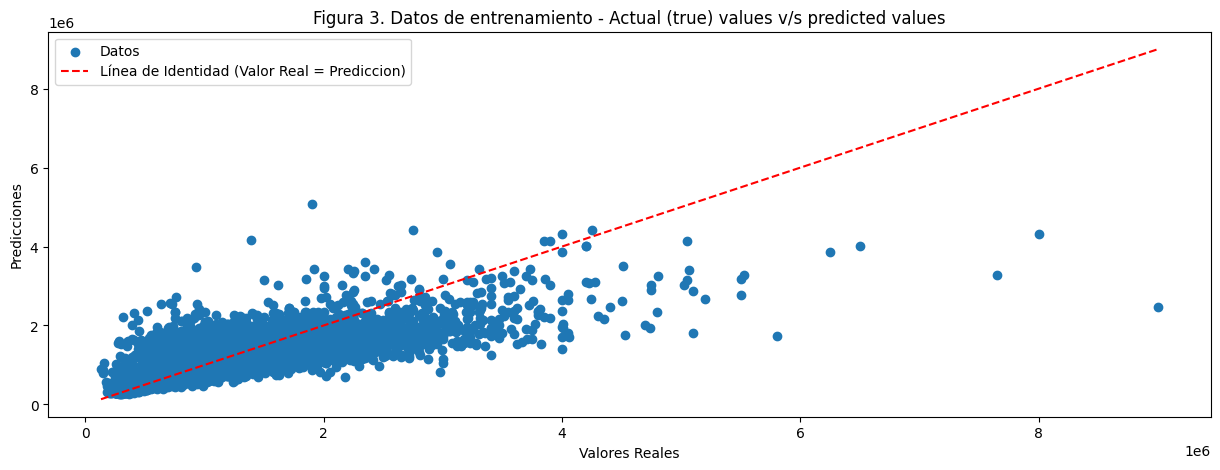

In [33]:
plt.figure(figsize=(15,5))

# Graficamos valores reales vs predicciones del modelo
plt.scatter(y_train.reset_index(drop=True), list(y_train_pred), label='Datos')
plt.title('Figura 3. Datos de entrenamiento - Actual (true) values v/s predicted values')

# Añadimos la identidad (x=y) para ver si el modelo es acertado

## valores max y min para limites de grafica
min_val = min(min(y_train.values.flatten()), min(list(y_train_pred)))
max_val = max(max(y_train.values.flatten()), max(list(y_train_pred)))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    label='Línea de Identidad (Valor Real = Prediccion)'
)
# Etiquetas y titulos
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.legend()
plt.show()

<Axes: xlabel='abs_error', ylabel='Count'>

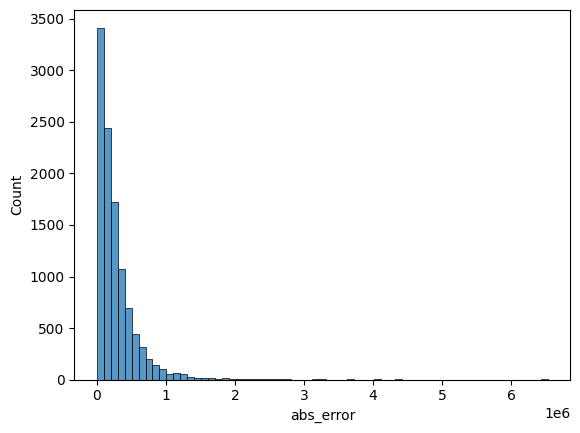

In [61]:
sns.histplot(
    eval_res,
    x="abs_error",
    binwidth=100_000
)

In [62]:
eval_res.query("abs_error < 2000").shape

(78, 3)

In [36]:
eval_res.query("abs_error  < 2000")

,price,price_predicted,abs_error
33,450000,451000.0,1000.0
138,1110000,1108600.0,1400.0
414,1270000,1269000.0,1000.0
417,612500,613500.0,1000.0
537,2050000,2049600.0,400.0
...,...,...,...
10453,505000,506400.0,1400.0
10507,1175000,1176200.0,1200.0
10526,685000,685000.0,0.0
10806,860000,861000.0,1000.0


In [64]:
neighbours = [1, 2, 5, 10, 20, 50, 70, 100]

models_regresion = {
    i: KNeighborsRegressor(n_neighbors=i)
    for i in neighbours
    }


In [65]:
models_regresion

{1: KNeighborsRegressor(n_neighbors=1),
 2: KNeighborsRegressor(n_neighbors=2),
 5: KNeighborsRegressor(),
 10: KNeighborsRegressor(n_neighbors=10),
 20: KNeighborsRegressor(n_neighbors=20),
 50: KNeighborsRegressor(n_neighbors=50),
 70: KNeighborsRegressor(n_neighbors=70),
 100: KNeighborsRegressor(n_neighbors=100)}

In [66]:
errors_train = []
errors_test = []

for model_name in models_regresion.keys():

    print("Modelo:", model_name)
    model = models_regresion[model_name]

    # Ajusta el modelo con los datos de prueba
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # error en conjunto de entrenamiento y prueba
    error_train = root_mean_squared_error(y_train, y_train_pred)
    error_test = root_mean_squared_error(y_test, y_test_pred)

    errors_train.append(error_train)
    errors_test.append(error_test)

    # errores
    print("Error RSME en train:", round(error_train,2) )
    print("Error RSME en test:", round(error_test,2) )

    print("----------------------------------------------")

    


Modelo: 1
Error RSME en train: 68690.23
Error RSME en test: 656969.49
----------------------------------------------
Modelo: 2
Error RSME en train: 301731.56
Error RSME en test: 581585.27
----------------------------------------------
Modelo: 5
Error RSME en train: 405839.65
Error RSME en test: 541162.76
----------------------------------------------
Modelo: 10
Error RSME en train: 446150.71
Error RSME en test: 523399.06
----------------------------------------------
Modelo: 20
Error RSME en train: 477559.57
Error RSME en test: 522497.47
----------------------------------------------
Modelo: 50
Error RSME en train: 506807.69
Error RSME en test: 535511.92
----------------------------------------------
Modelo: 70
Error RSME en train: 517435.32
Error RSME en test: 541676.07
----------------------------------------------
Modelo: 100
Error RSME en train: 526904.0
Error RSME en test: 548008.27
----------------------------------------------


In [40]:
knn_errors_train = pd.DataFrame(
    {
        "k": neighbours,
        "type": "train",
        "rmse": errors_train,
    }
)

knn_errors_test = pd.DataFrame(
    {
        "k": neighbours,
        "type": "test",
        "rmse": errors_test,
    }
)

In [41]:
pd.concat([knn_errors_train, knn_errors_test])

,k,type,rmse
0,1,train,68690.232815
1,2,train,301731.564574
2,5,train,405839.647788
3,10,train,446150.714619
4,20,train,477559.574448
5,50,train,506807.690157
6,70,train,517435.316855
7,100,train,526903.999420
0,1,test,656969.487823
1,2,test,581585.273542


In [42]:
knn_errors = pd.DataFrame(
    {
        "k": neighbours,
        "rmse_train": errors_train,
        "rmse_test": errors_test
    }
)

knn_errors

,k,rmse_train,rmse_test
0,1,68690.232815,656969.487823
1,2,301731.564574,581585.273542
2,5,405839.647788,541162.764807
3,10,446150.714619,523399.055342
4,20,477559.574448,522497.472489
5,50,506807.690157,535511.919320
6,70,517435.316855,541676.068394
7,100,526903.999420,548008.268083


<Axes: xlabel='k', ylabel='rmse'>

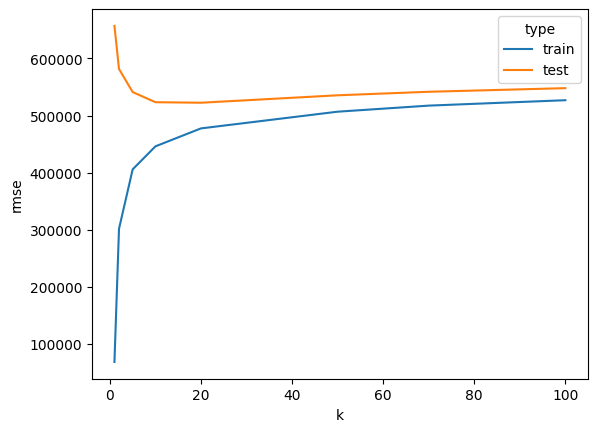

In [43]:
sns.lineplot(
    pd.concat([knn_errors_train, knn_errors_test]),
    x="k",
    y="rmse",
    hue="type",
    markers=True, dashes=True
)

**Questions:**

* Repite el ejercicio pero incorporando más columnas de tipo numérico (por ejemplo `YearBuilt`)
  * Si existen valores nulos asegurate de imputarles un valor usando la media de dicha columna
* Usando este nuevo ejercicio contesta:
  * ¿El error aumento o disminuyo?,
  * ¿Cual fue el numero de vecino?